In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
# Starting values
u_n = np.array([2, 3, 3, 2, 1])
g_n = np.array([1, 1, 3])

conv_size = len(u_n) + len(g_n) - 1
matrix_size = u_n.size if len(u_n) > len(g_n) else g_n.size

# Define an empty matrix
matrix = np.zeros((len(g_n), len(u_n)))


for i in range(np.size(u_n)):
    for j in range(np.size(g_n)):
        matrix[j, i] = u_n[i] * g_n[j]

print("Matrix:")
print(matrix)

answer = []

# Iterate through the upper anti-diagnols
for col in range(len(u_n)):

    startcol = col
    startrow = 0

    value = 0

    while(startcol >= 0 and startrow < len(g_n)):
        value += matrix[startrow][startcol]
        startcol -= 1
        startrow += 1

    answer.append(value)

# Iterate through the lower anti-diagnols
for row in range(1, len(g_n)):
    startrow = row
    startcol = matrix_size - 1

    value = 0

    while(startrow < len(g_n) and startcol >= 0):
        value += matrix[startrow][startcol]
        startcol -= 1
        startrow += 1

    answer.append(value)

print("Convolution result:")
print([int(x) for x in answer])



Matrix:
[[2. 3. 3. 2. 1.]
 [2. 3. 3. 2. 1.]
 [6. 9. 9. 6. 3.]]
Convolution result:
[2, 5, 12, 14, 12, 7, 3]


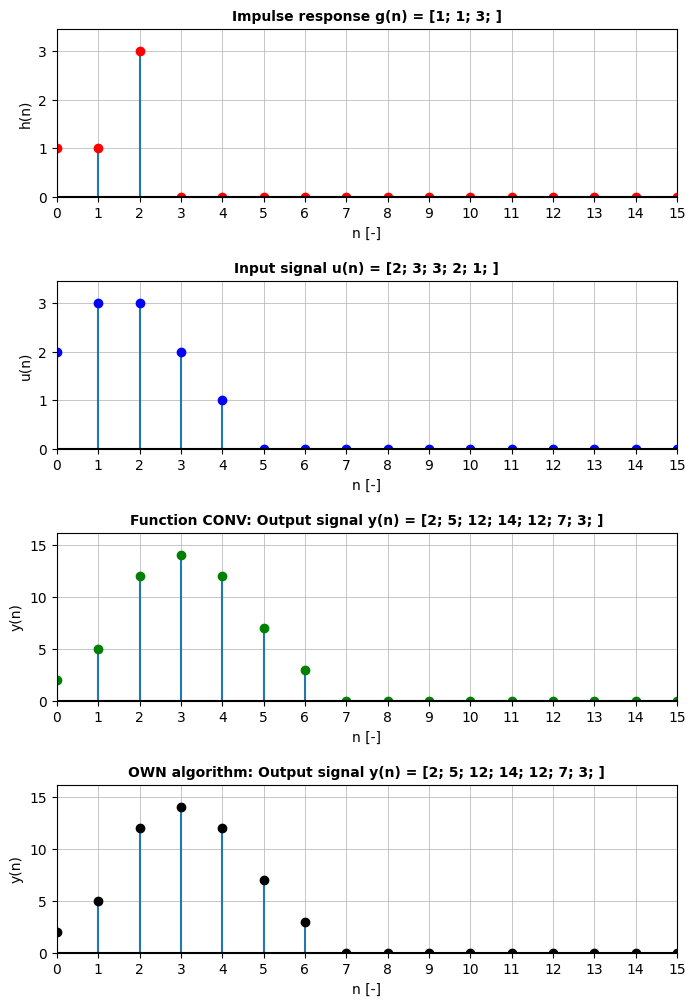

In [ ]:
y_n_conv = np.convolve(u_n, g_n)

# Simulated 'OWN algorithm' output (same as y_n_conv in this case)
y_n_own = y_n_conv.copy()

# Define the x-axis range (0 to 15 as seen in the image)
N = 16
n = np.arange(N)

g_n_padded = np.pad(g_n, (0, N - len(g_n)), 'constant')
u_n_padded = np.pad(u_n, (0, N - len(u_n)), 'constant')
y_n_conv_padded = np.pad(y_n_conv, (0, N - len(y_n_conv)), 'constant')
y_n_own_padded = np.pad(y_n_own, (0, N - len(y_n_own)), 'constant')

fig, axs = plt.subplots(4, 1, figsize=(8, 12))
plt.subplots_adjust(hspace=0.5)

# Impulse
axs[0].stem(n, g_n_padded, linefmt='-', markerfmt='ro', basefmt='k-')
axs[0].set_title('Impulse response g(n) = [1; 1; 3; ]', fontweight='bold', fontsize=10)
axs[0].set_ylabel('h(n)')

# Input
axs[1].stem(n, u_n_padded, linefmt='-', markerfmt='bo', basefmt='k-')
axs[1].set_title('Input signal u(n) = [2; 3; 3; 2; 1; ]', fontweight='bold', fontsize=10)
axs[1].set_ylabel('u(n)')

# From conv function
axs[2].stem(n, y_n_conv_padded, linefmt='-', markerfmt='go', basefmt='k-')
axs[2].set_title('Function CONV: Output signal y(n) = [2; 5; 12; 14; 12; 7; 3; ]', fontweight='bold', fontsize=10)
axs[2].set_ylabel('y(n)')

# From my algorithm
axs[3].stem(n, y_n_own_padded, linefmt='-', markerfmt='ko', basefmt='k-')
axs[3].set_title('OWN algorithm: Output signal y(n) = [2; 5; 12; 14; 12; 7; 3; ]', fontweight='bold', fontsize=10)
axs[3].set_ylabel('y(n)')

# Format all subplots
for ax in axs:
    ax.grid(True, which='both', linestyle='-', linewidth=0.5)
    ax.set_xticks(np.arange(0, 16, 1))
    ax.set_xlim([0, 15])
    ax.set_xlabel('n [-]')
    
    # Optional: adjust y-axis limits slightly for better visibility like the image
    y_max = ax.get_ylim()[1]
    ax.set_ylim([0, y_max * 1.1])

plt.show()

# Conclusion
In conclusion the task was a good exercise in implementing a one-dimensional convolution algorithm from first principles. The implemented algorithm produces results consistent with NumPy's internal `np.convolve()` function, validating the approach. Understanding the internal mechanics of convolution through manual implementation provides valuable insight into signal processing fundamentals.